# Exercise 1

## Exercise 1.1

write a code that prints the following pattern. Try to use as few loops as possible.

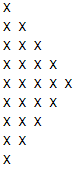

Avoid using trivial solutions like:

print('X')

print('X X')

print('X X X')

.....

print('X X X')

print('X X')

print('X')


In [4]:
for i in range(1, 6):
    print('X ' * i)

for i in range(4, 0, -1):
    print('X ' * i)

X 
X X 
X X X 
X X X X 
X X X X X 
X X X X 
X X X 
X X 
X 


## Exercise 1.2

Write a script that will sum all numbers in the following string. You can split each number into single digits, so for example, you can consider 45 to be 4 and 5

In [7]:
input_str = "n45as29@#8ss6"
suma = sum(int(c) for c in input_str if c.isdigit())
print(suma)

34


## Exercise 1.3

Write a script that will convert an arbitrary integer to a binary number (the number will be represented as a string with only *0* and *1*). Avoid using the *bin()* function or any other pythons default functions

In [6]:
def int_to_bin(n):
    if n == 0: return '0'
    bits = []
    while n:
        bits.append(str(n % 2))
        n //= 2
    return ''.join(bits[::-1])

print(int_to_bin(10))

1010


## Exercise 1.4 - The Fibonacci Sequence:

The Fibonacci Sequence is a series of numbers. The following number is found by adding up the two numbers before it. The first two numbers are 0 and 1. For example, 0, 1, 1, 2, 3, 5, 8, 13. The following number in this series above is 8 + 13 = 21


Your task is to implement a function *fibonacci* that takes an integer as an input and returns a list that contains all Fibonacci numbers with values lower than the input integer

Example:

*print(fibonaci(10))*

[0, 1, 1, 2, 3, 5, 8]


In [8]:
def fibonacci(upper_threshold):
    fib = [0, 1]
    while True:
        next_fib = fib[-1] + fib[-2]
        if next_fib >= upper_threshold:
            return fib
        fib.append(next_fib)

print(fibonacci(10))

[0, 1, 1, 2, 3, 5, 8]


#### Advanced

Try to implement the function using multiple approaches: *Iterative approach*, *Recusrion*, *Memoization*

## Exercise 1.5. -  Rock, Paper, Scissors game:

#### basic

*Rock, Paper, Scissors* is a well-known and straightforward game. If you do not know the rules, google them. We will write a code for the Rock, Paper, Scissors game where the user plays against a random computer. The code can be written into one function *rock_paper_scissors*.

Notes:
- This implementation uses the **random** library to enable the computer to make a random choice.
- Keyword **Input** may be helpful. Check it
- After the function is run, the program will ask you about your movement, which you type in
- The game is case-insensitive for user input (e.g., "rock", "Rock", and "ROCK" are all valid).
- This script plays one round of the game.
- The script prints the result ('You lose', 'You win', 'It is a tie')


In [9]:
import random

def rock_paper_scissors():
    choices = ['rock', 'paper', 'scissors']
    user = input('Elige (rock/paper/scissors): ').lower()
    comp = random.choice(choices)
    print(f'Computadora: {comp}')

    if user == comp:
        print('Tie')
    elif (user == 'rock' and comp == 'scissors') or \
         (user == 'paper' and comp == 'rock') or \
         (user == 'scissors' and comp == 'paper'):
        print('You win')
    else:
        print('You lose')

rock_paper_scissors()

Elige (rock/paper/scissors): rock
Computadora: paper
You lose


#### Advanced

Extend the Rock, Paper, Scissors game to be able to play *n* rounds.

Notes:
- The scrips will contain two counters - user score and computer score
- After each run, the script prints the current scores and rounds.
- When the number of rounds is reached, the script prints the result ('You lose', 'You win', 'It is a tie')

# Exercise 2

The purpose of this excercise is to practise working with NumPy library

## Exercise 2.1


In this exercise, you will work with NumPy arrays and learn how to efficiently modify and process them using both loops and vectorized operations. Your task is to:

1. Implement the function *create_array_nxn* that generates an n×n NumPy array filled with numbers from n² - 1 down to 0
2. Using a loop-based approach (for-loop, while-loop), implement the function *apply_threshold_loop* that takes any NumPy array and replaces all numbers below a user-defined threshold with 0.
3. Implement function *apply_threshold_vectorized* that performs the same operation as *apply_threshold_loop*, but without loops, using NumPy vectorized operations
4. Implement function *compare_performance* that compares the execution time of functions *apply_threshold_vectorized* and *apply_threshold_loop* with **time** library and print the results


**Additional Notes**:

- Ensure n is a positive integer (n > 0).
- Use the time library to measure execution times for performance comparison.
- The function *compare_performance(n, threshold)* should:
    - Generate an n×n array.
    - Apply both loop-based and vectorized thresholding.
    - Print execution times.

In [10]:
import numpy as np
import time

In [11]:
def create_array_nxn(n: int) -> np.ndarray:
    return np.arange(n*n-1, -1, -1).reshape(n, n)

In [12]:
def apply_threshold_loop(arr: np.ndarray, threshold: int) -> np.ndarray:
    for i in range(len(arr)):
        for j in range(len(arr[0])):
            if arr[i,j] < threshold:
                arr[i,j] = 0
    return arr

In [13]:
def apply_threshold_vectorized(arr: np.ndarray, threshold: int) -> np.ndarray:
    arr[arr < threshold] = 0
    return arr

In [14]:
def compare_performance(n: int, threshold: int) -> None:
    arr = create_array_nxn(n).copy()

    start = time.time()
    loop_res = apply_threshold_loop(arr.copy(), threshold)
    loop_time = time.time() - start

    start = time.time()
    vec_res = apply_threshold_vectorized(arr.copy(), threshold)
    vec_time = time.time() - start

    print(f"Loop: {loop_time:.6f}s, Vectorized: {vec_time:.6f}s")

## Exercise 2.2 - Digi display

#### basic

The task will be to create a simulation of a Digi display that will be able to display an arbitrary integer
   
*hint: to show the image, use the library matplotlib.pyplot. Also, you may find function *np.concatenate* helpful

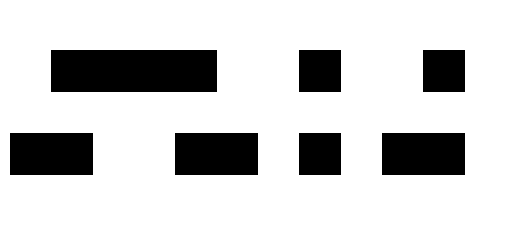

In [25]:
import numpy as np
import time
import matplotlib.pyplot as plt

numbs = {
    "1": np.array([[0,1,1],[1,0,1],[0,0,1],[0,0,1],[0,0,1]]),
    "2": np.array([[1,1,1],[0,0,1],[1,1,1],[1,0,0],[1,1,1]]),
    "3": np.array([[1,1,1],[0,0,1],[1,1,1],[0,0,1],[1,1,1]]),
    "4": np.array([[1,0,1],[1,0,1],[1,1,1],[0,0,1],[0,0,1]]),
    "5": np.array([[1,1,1],[1,0,0],[1,1,1],[0,0,1],[1,1,1]]),
    "6": np.array([[1,1,1],[1,0,0],[1,1,1],[1,0,1],[1,1,1]]),
    "7": np.array([[1,1,1],[0,0,1],[0,0,1],[0,0,1],[0,0,1]]),
    "8": np.array([[1,1,1],[1,0,1],[1,1,1],[1,0,1],[1,1,1]]),
    "9": np.array([[1,1,1],[1,0,1],[1,1,1],[0,0,1],[1,1,1]]),
    "0": np.array([[1,1,1],[1,0,1],[1,0,1],[1,0,1],[1,1,1]])
}


def show_in_digi(input_integer: int) -> None:
    digits = list(str(input_integer))  # ['5','2','8','9']
    display = np.hstack([numbs[d] for d in digits])
    plt.imshow(display, cmap='gray')
    plt.axis('off')
    plt.show()


show_in_digi(5289)

show_in_digi(5289) will show:


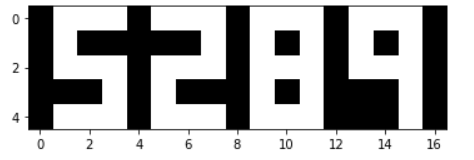

*hint2: you may find the following dict usefull*

In [ ]:
numbs = {
      "1": np.array([[0, 1, 1], [1, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 1
      "2": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]), # 2
      "3": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 3
      "4": np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]), # 4
      "5": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 5
      "6": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 6
      "7": np.array([[1, 1, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 7
      "8": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 8
      "9": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 9
      "0": np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]), # 0
  }

#### advanced

Extend your *show_in_digi* function to be able to display an arbitary float number and negative numbers

# Exercise 3 - Playing with California Housing Dataset

The purpose of this exercise is to learn basic operations of **pandas** library. Use *california_housing_dataset* you can find in google colab to do following operations:

- check what *dataset.describe()* does

- display all rows where *total_bedrooms* column is bigger than 310

- drop also first and last row

- save a mean of values in *households* columns to variable, using *matplotlib* display number of households in the graph (x-axis would be ID, y-axis - numbers of households) as dots with the same color, display also mean as a single line in the graph with different color as dots is

 - check if any of the columns contain NaN values, if yes, replace the NaN values with the arithmetic mean of the whole dataset

 - display *lat* and *long* into plot, *lat* would be on *x* axis and *long* on *y* axis

- choose two arbitrary columns and normalize all values inside using *min-max normalization*:

- Create a Correlation Matrix from all columns

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

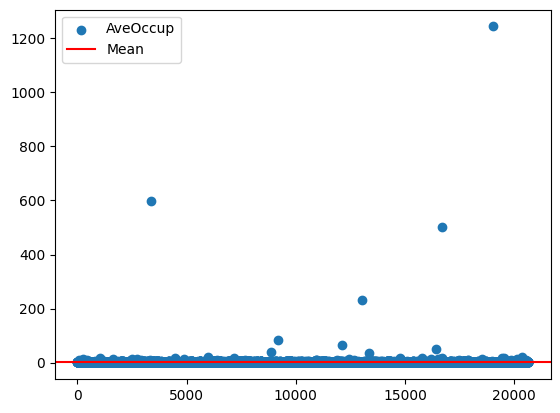

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


/tmp/ipython-input-2079853053.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AveBedrms'].fillna(df['AveBedrms'].mean(), inplace=True)


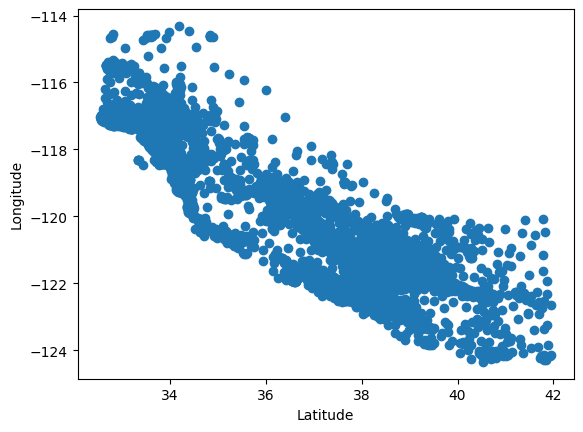

                   MedInc  HouseAge  AveRooms  AveBedrms  Population  \
MedInc           1.000000 -0.119034  0.326895  -0.062040    0.004834   
HouseAge        -0.119034  1.000000 -0.153277  -0.077747   -0.296244   
AveRooms         0.326895 -0.153277  1.000000   0.847621   -0.072213   
AveBedrms       -0.062040 -0.077747  0.847621   1.000000   -0.066197   
Population       0.004834 -0.296244 -0.072213  -0.066197    1.000000   
AveOccup         0.018766  0.013191 -0.004852  -0.006181    0.069863   
Latitude        -0.079809  0.011173  0.106389   0.069721   -0.108785   
Longitude       -0.015176 -0.108197 -0.027540   0.013344    0.099773   
MedInc_norm      1.000000 -0.119034  0.326895  -0.062040    0.004834   
Population_norm  0.004834 -0.296244 -0.072213  -0.066197    1.000000   

                 AveOccup  Latitude  Longitude  MedInc_norm  Population_norm  
MedInc           0.018766 -0.079809  -0.015176     1.000000         0.004834  
HouseAge         0.013191  0.011173  -0.108197   

In [29]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
housing = fetch_california_housing(as_frame=True)
df = pd.DataFrame(housing.data)

print(df.describe())

df_filtered = df[df['Population'] > 310]
print(df_filtered)

df_filtered = df_filtered.iloc[1:-1]
print(df_filtered.shape)

mean_occup = df['AveOccup'].mean()
plt.scatter(range(len(df)), df['AveOccup'], label='AveOccup')
plt.axhline(mean_occup, color='red', label='Mean')
plt.legend()
plt.show()

print(df.isnull().sum())
df['AveBedrms'].fillna(df['AveBedrms'].mean(), inplace=True)

plt.scatter(df['Latitude'], df['Longitude'])
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

df['MedInc_norm'] = (df['MedInc'] - df['MedInc'].min()) / (df['MedInc'].max() - df['MedInc'].min())
df['Population_norm'] = (df['Population'] - df['Population'].min()) / (df['Population'].max() - df['Population'].min())

print(df.corr())